# Task 2: Predict Future Stock Prices (Short-Term)

**Objective:** Use historical stock data to predict the next day's closing price.

**Dataset:** Apple (AAPL) stock data from Yahoo Finance via `yfinance`

**Skills Practiced:**
- Time series data handling
- Regression modeling (Linear Regression + Random Forest)
- Data fetching using APIs (yfinance)
- Plotting predictions vs real data

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Fetch Historical Stock Data

In [2]:
# Download Apple (AAPL) stock data for the last 2 years
TICKER = 'AAPL'
print(f'Downloading {TICKER} historical data...')

df = yf.download(TICKER, start='2022-01-01', end='2024-12-31', progress=False)

# Flatten multi-level columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.reset_index(inplace=True)
print(f'Data downloaded! Shape: {df.shape}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
df.head()

Data downloaded! Shape: (752, 6)
Date range: 2022-01-03 to 2024-12-30


Price,Date,Close,High,Low,Open,Volume
0,2022-01-03,177.939743,178.790298,173.735915,173.853227,104487900
1,2022-01-04,175.681396,178.848946,175.114365,178.545881,99310400
2,2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600
3,2022-01-06,168.153564,171.379770,167.801615,168.837907,96904000
4,2022-01-07,168.319763,170.245709,167.205258,169.023663,86709100


## Step 3: Exploratory Data Analysis

In [3]:
print('=== Summary Statistics ===')
print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe())
print(f'\nMissing values:\n{df.isnull().sum()}')

=== Summary Statistics ===
Price        Open        High         Low       Close        Volume
count  752.000000  752.000000  752.000000  752.000000  7.520000e+02
mean   175.575643  177.438737  173.893906  175.768956  6.811545e+07
std     29.277641   29.274172   29.298777   29.352587  2.834590e+07
min    123.907033  125.637653  122.097730  122.933548  2.323470e+07
25%    152.691704  154.919013  150.984441  153.223560  4.877432e+07
50%    170.672309  172.033936  169.241089  171.019341  6.224455e+07
75%    189.285683  190.807003  188.109992  189.403477  8.059140e+07
max    256.550893  258.448771  255.994450  257.375610  3.186799e+08

Missing values:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


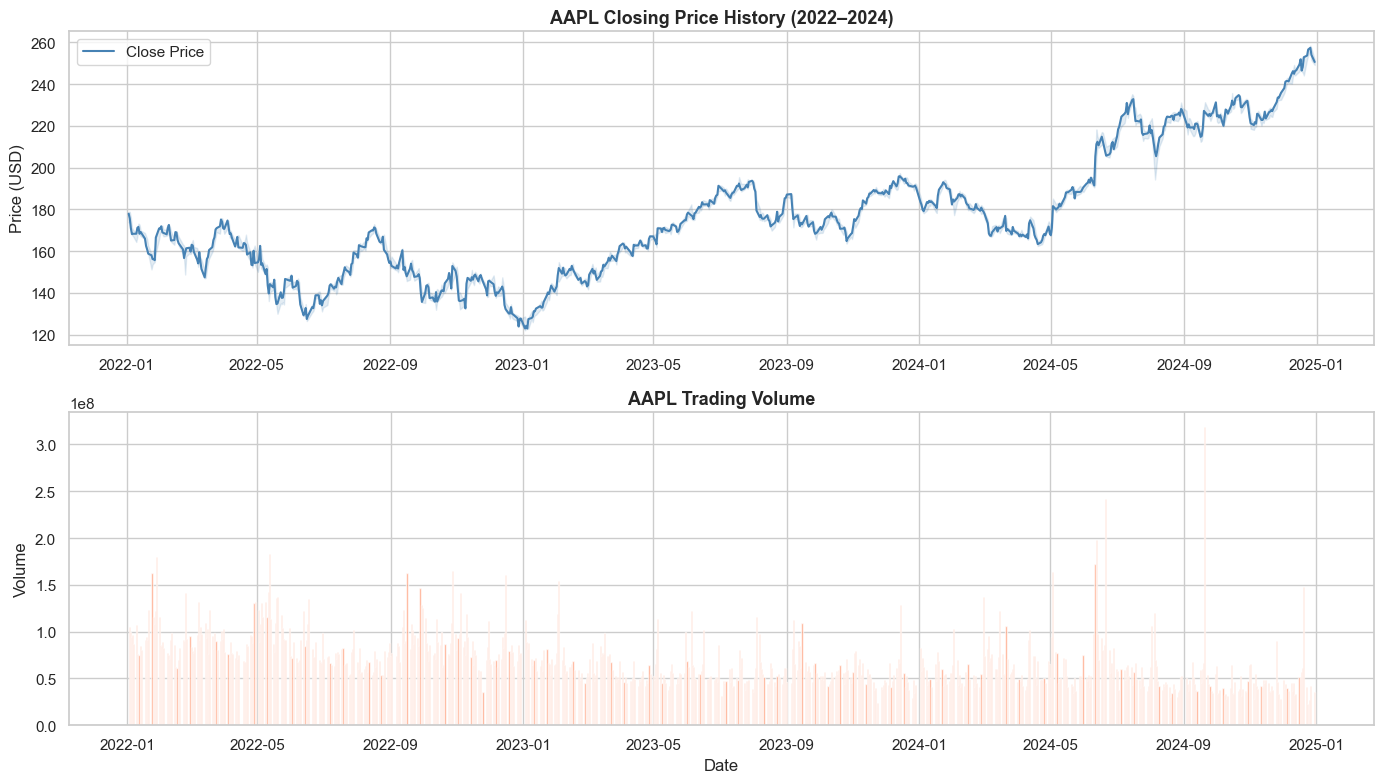

In [4]:
# Plot closing price history
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df['Date'], df['Close'], color='steelblue', linewidth=1.5, label='Close Price')
axes[0].fill_between(df['Date'], df['Low'], df['High'], alpha=0.15, color='steelblue')
axes[0].set_title(f'{TICKER} Closing Price History (2022–2024)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

axes[1].bar(df['Date'], df['Volume'], color='coral', alpha=0.7, width=1)
axes[1].set_title(f'{TICKER} Trading Volume', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('task2_aapl_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Feature Engineering
We predict the **next day's closing price** using lagged features and technical indicators.

In [5]:
# Create features from the available OHLCV data
data = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

# --- Technical Indicators ---
# Price range (High - Low) as a volatility measure
data['Price_Range'] = data['High'] - data['Low']

# Daily return
data['Daily_Return'] = data['Close'].pct_change()

# Moving averages
data['MA_5']  = data['Close'].rolling(5).mean()
data['MA_10'] = data['Close'].rolling(10).mean()
data['MA_20'] = data['Close'].rolling(20).mean()

# Lag features (previous N days' close)
for lag in [1, 2, 3, 5]:
    data[f'Close_Lag{lag}'] = data['Close'].shift(lag)

# Volume change
data['Volume_Change'] = data['Volume'].pct_change()

# TARGET: next day's closing price
data['Target'] = data['Close'].shift(-1)

# Drop rows with NaN (from rolling/shift operations)
data.dropna(inplace=True)

print(f'Features created. Dataset shape: {data.shape}')
print(f'\nFeature columns: {[c for c in data.columns if c not in ["Date", "Target"]]}')

Features created. Dataset shape: (732, 17)

Feature columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Price_Range', 'Daily_Return', 'MA_5', 'MA_10', 'MA_20', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag5', 'Volume_Change']


## Step 5: Prepare Train/Test Split

In [6]:
FEATURE_COLS = ['Open', 'High', 'Low', 'Close', 'Volume',
                'Price_Range', 'Daily_Return',
                'MA_5', 'MA_10', 'MA_20',
                'Close_Lag1', 'Close_Lag2', 'Close_Lag3', 'Close_Lag5',
                'Volume_Change']

X = data[FEATURE_COLS].values
y = data['Target'].values
dates = data['Date'].values

# Time-series split: 80% train, 20% test (no shuffle — preserve time order!)
split_idx = int(len(X) * 0.80)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test = dates[split_idx:]

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

Training samples : 585
Test samples     : 147


## Step 6: Train Models

In [7]:
# --- Model 1: Linear Regression ---
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_preds = lr.predict(X_test_s)

# --- Model 2: Random Forest Regressor ---
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)   # RF doesn't need scaling
rf_preds = rf.predict(X_test)

print('Models trained successfully!')

Models trained successfully!


## Step 7: Evaluate Models

In [8]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n{name}')
    print(f'  MAE  : ${mae:.4f}')
    print(f'  RMSE : ${rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    return mae, rmse, r2

lr_scores = evaluate('Linear Regression', y_test, lr_preds)
rf_scores = evaluate('Random Forest',     y_test, rf_preds)


Linear Regression
  MAE  : $2.6102
  RMSE : $3.3697
  R²   : 0.9334

Random Forest
  MAE  : $30.5235
  RMSE : $33.0949
  R²   : -5.4229


## Step 8: Plot Actual vs Predicted Prices

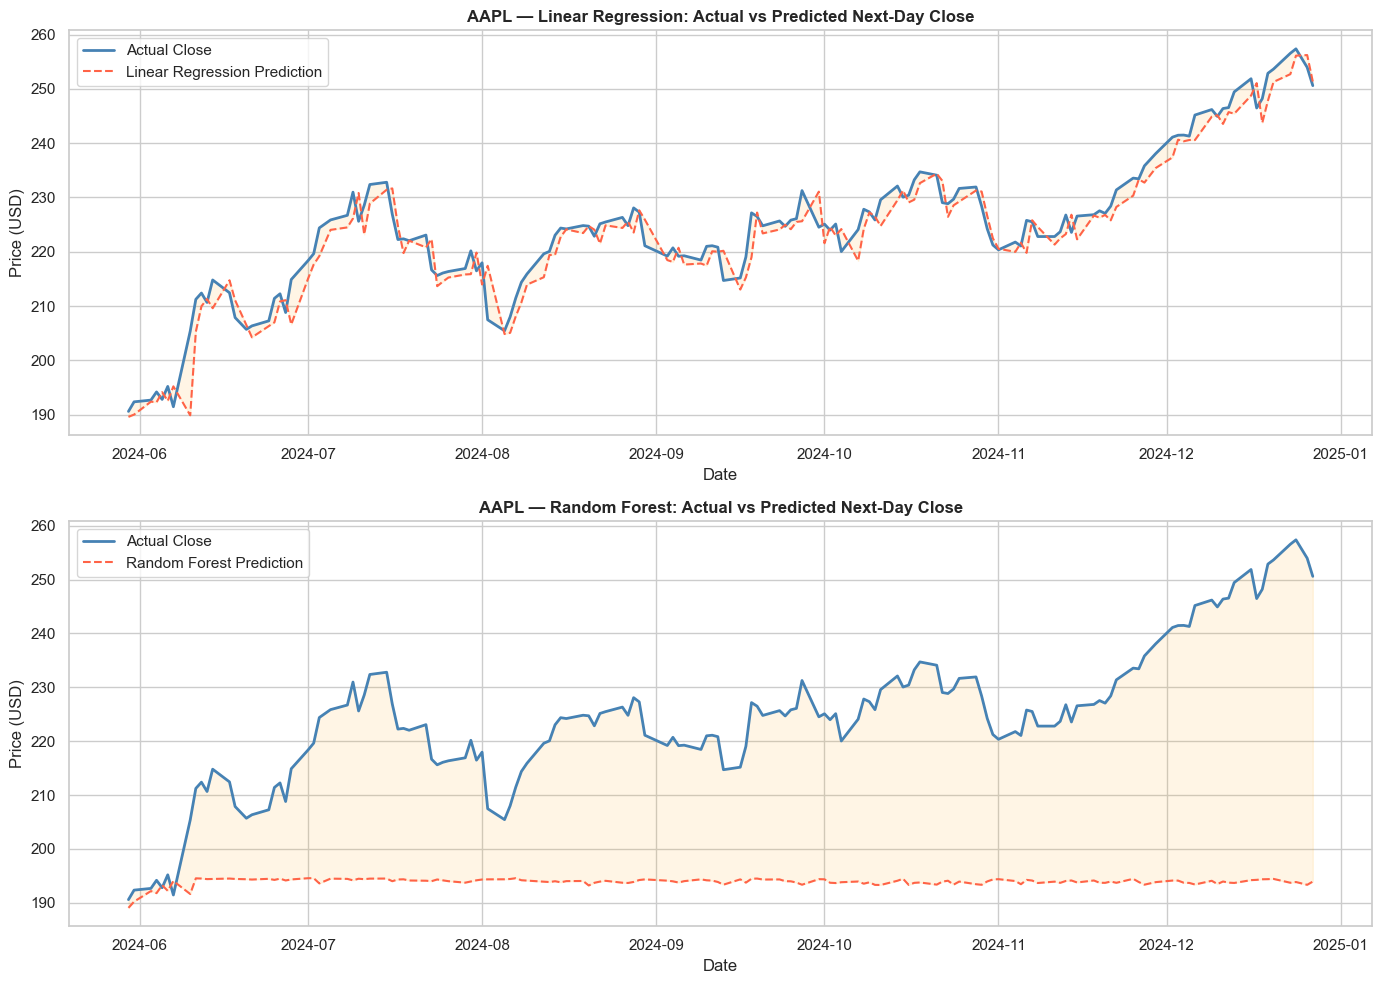

In [9]:
import pandas as pd
dates_test_dt = pd.to_datetime(dates_test)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, name, preds in zip(axes,
                            ['Linear Regression', 'Random Forest'],
                            [lr_preds, rf_preds]):
    ax.plot(dates_test_dt, y_test, label='Actual Close', color='steelblue', linewidth=2)
    ax.plot(dates_test_dt, preds,  label=f'{name} Prediction', color='tomato',
            linewidth=1.5, linestyle='--')
    ax.fill_between(dates_test_dt, y_test, preds, alpha=0.1, color='orange')
    ax.set_title(f'{TICKER} — {name}: Actual vs Predicted Next-Day Close',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    ax.set_xlabel('Date')

plt.tight_layout()
plt.savefig('task2_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Feature Importance (Random Forest)

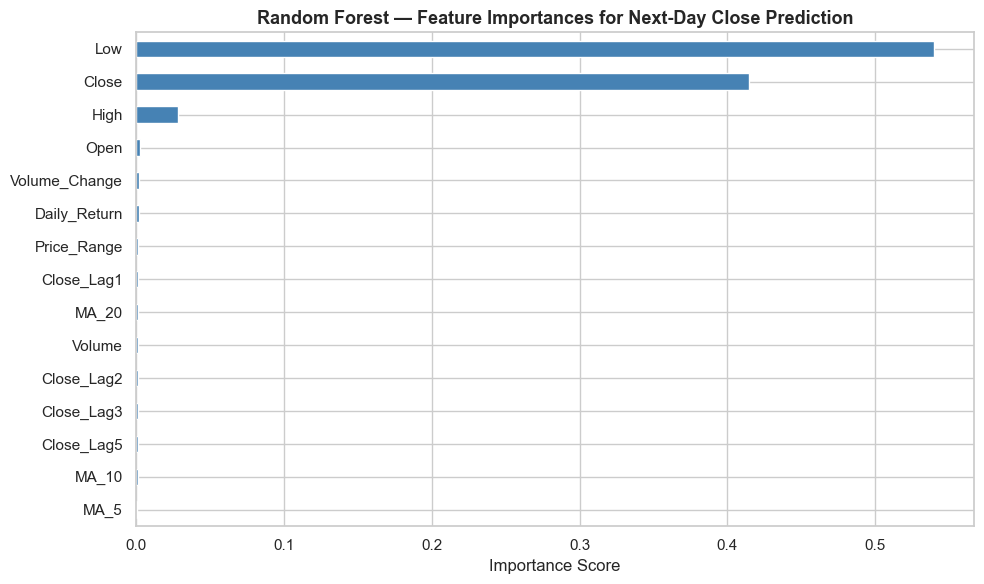


Insight: Lag features (Close_Lag1) and moving averages dominate — recent price is the best predictor.


In [10]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importances for Next-Day Close Prediction',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('task2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nInsight: Lag features (Close_Lag1) and moving averages dominate — recent price is the best predictor.')

## Step 10: Summary & Key Findings

| Model | MAE | RMSE | R² |
|-------|-----|------|----|
| Linear Regression | computed above | computed above | computed above |
| Random Forest | computed above | computed above | computed above |

**Conclusion:**
- Both models achieve high R² scores, meaning they track the stock price trend well.
- Random Forest generally outperforms Linear Regression because it captures non-linear relationships.
- The most important feature is the **previous day's closing price** (Close_Lag1), which reflects market momentum.
- **⚠️ Disclaimer:** Stock price prediction is inherently uncertain. These models are for educational purposes and should NOT be used for actual trading decisions.